# 선형회귀 실습 - 보스턴 주택 가격 예측

## 1. 라이브러리 임포트(import)

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
# sklearn 
from sklearn.<blank> import train_test_split  #학습셋과 검증셋의 분리

- [sklearn 주요 모듈]
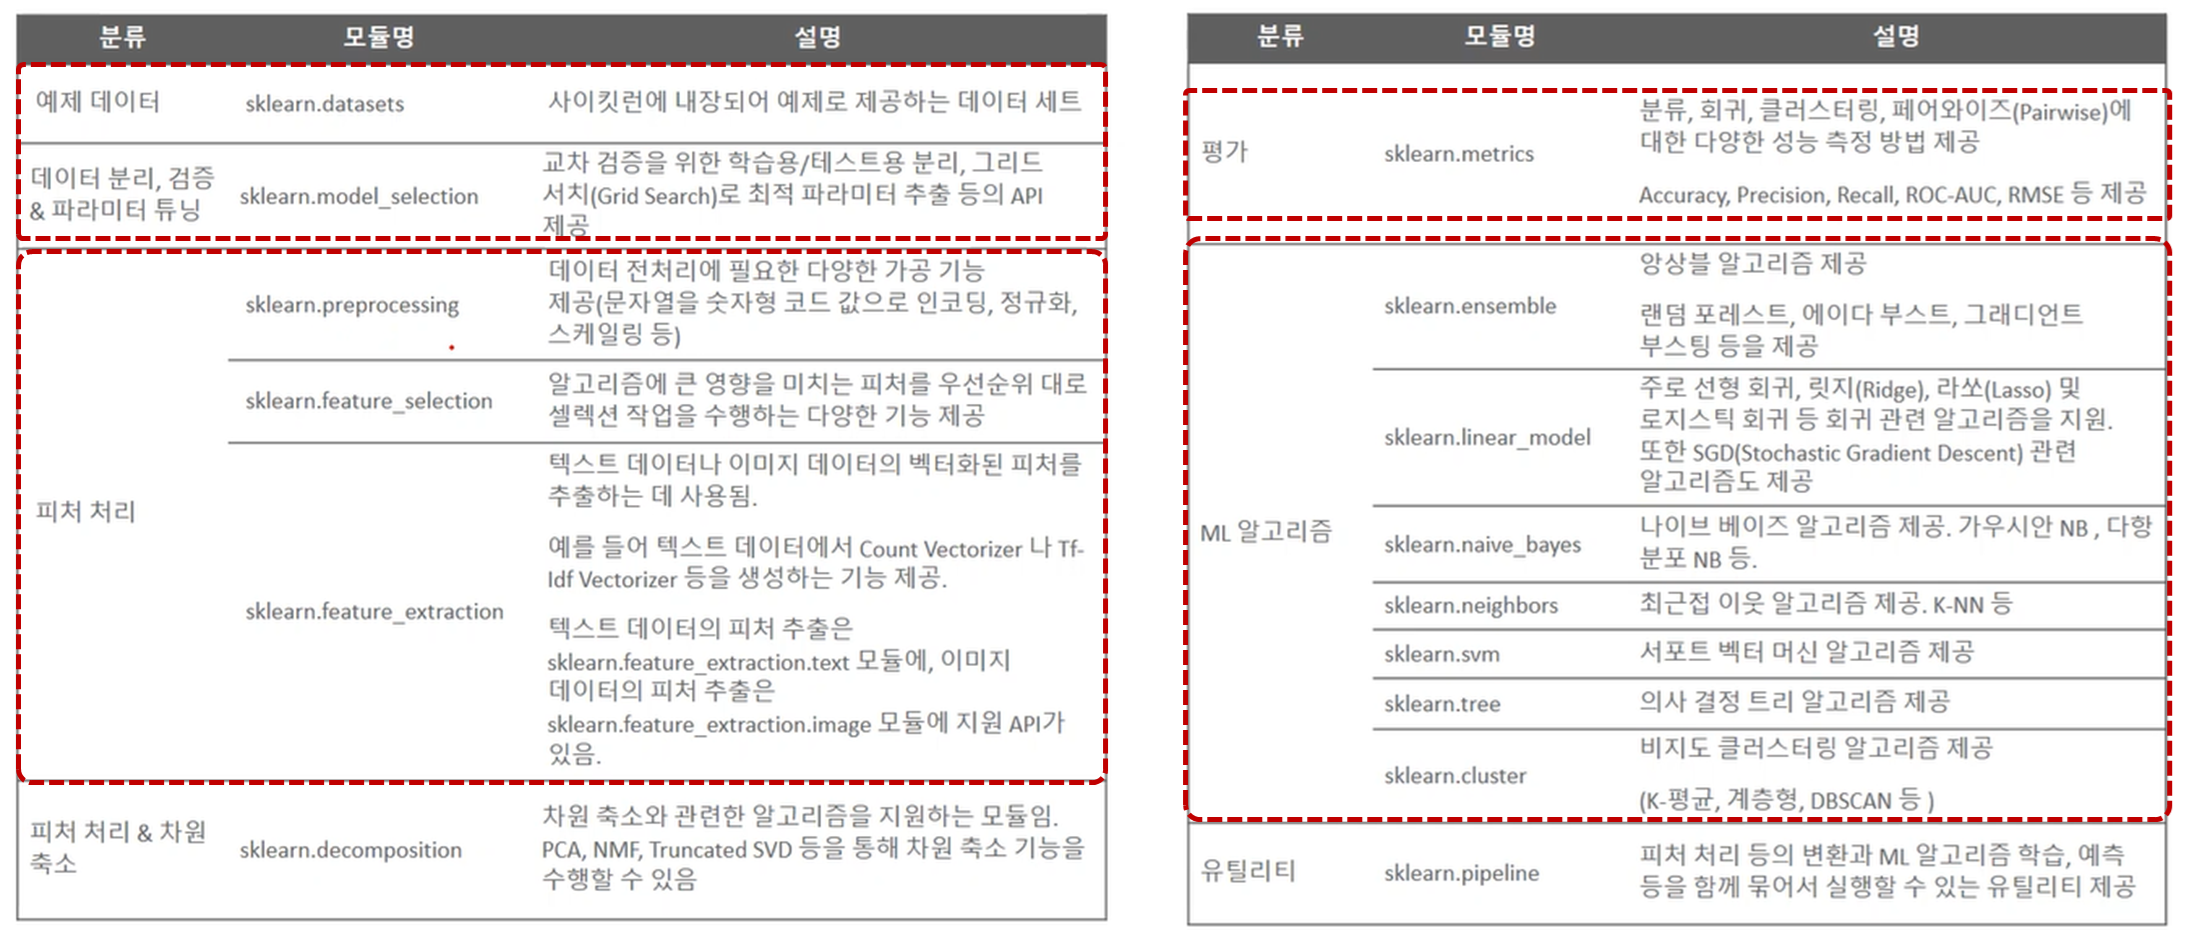

## 2. 데이타셋 로드

In [ ]:
bostonDF=pd.read_csv('boston.csv')

In [ ]:
bostonDF

[Features]
* CRIM: 지역별 범죄 발생률  
* ZN: 25,000평방피트를 초과하는 거주 지역의 비율
* INDUS: 비상업 지역 넓이 비율
* CHAS: 찰스강에 대한 더미 변수(강의 경계에 위치한 경우는 1, 아니면 0)
* NOX: 일산화질소 농도
* RM: 거주할 수 있는 방 개수
* AGE: 1940년 이전에 건축된 소유자 거주 주택의 비율
* DIS: 5개 주요 고용센터까지의 가중 거리
* RAD: 고속도로 접근 용이도
* TAX: 10,000달러당 재산세율
* PTRATIO: 지역의 교사와 학생 수 비율 (Pupil-Teacher)
* B: 지역의 흑인 거주 비율
* LSTAT: 하위 계층의 비율

[Target]
* PRICE: 보스턴 주택 가격

 ## 3. 학습과 검증 데이터 셋 분리

In [ ]:
# PRICE 열만 삭제하여 feature 생성
X_features=bostonDF.<blank>(["PRICE"], axis=1)
X_features

In [ ]:
# PRICE 열만 추출하여 target 생성
y_target=bostonDF[<blank>]

In [ ]:
X_train , X_val , y_train , y_val = train_test_split(<blank>,<blank>, test_size=0.3)

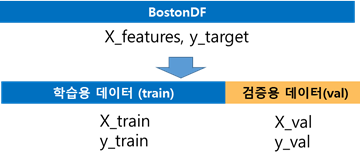

In [ ]:
X_train

In [ ]:
y_train

In [ ]:
X_val

In [ ]:
y_val

## 4. 선형회귀분석

### 4.1) 알고리즘 import

In [ ]:
from sklearn.<blank> import LinearRegression 

### 4.2) Estimator 설정

In [ ]:
linear_reg = LinearRegression()   

- https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html
- parameters, attributes, method 확인!

In [ ]:
# 절편 확인 (학습 전)
linear_reg.intercept_  #학습전이라 확인이 안됨(에러남)

In [ ]:
# 회귀계수 확인 (학습 전)
linear_reg.coef_  

### 4.3) 학습

In [ ]:
linear_reg.<blank>(X_train ,y_train)

In [ ]:
# 절편 확인 (학습후)
linear_reg.<blank>

In [ ]:
# 회귀계수 확인 (학습후)
linear_reg.<blank>

In [ ]:
# 회귀계수의 열이름 확인
X_features.columns

In [ ]:
#회귀계수값을 DataFrame으로 작성 - data만 설정
coeff = pd.DataFrame(data = np.round(linear_reg.coef_,1))
coeff

In [ ]:
#회귀계수값을 DataFrame으로 작성
coeff = pd.DataFrame(data = np.round(linear_reg.coef_,1), 
                    index= X_features.columns,
                    columns = ['coef_'])
coeff

In [ ]:
# coeff를 큰 값 순으로 정렬
coeff.sort_values(by=['coef_'], ascending=False)

### 4.4) 예측

In [ ]:
y_preds = linear_reg.<blank>(X_val)

In [ ]:
# 예측값 확인 
y_preds

In [ ]:
# 실제값 확인 
y_val

In [ ]:
# 예측 결과 가시화
plt.title('Linear Regression')
plt.xlabel('Actual Vlaues')
plt.ylabel('Predicted Vlaues')
plt.plot(y_val, y_val)       #실제값
plt.scatter(y_val, y_preds)   #예측값
plt.axis([5,55,5,55])
plt.show()

### 4.5) 평가

- 평가지표: MSE, RMSE, R-Square

In [ ]:
# 평가지표(함수) import
from sklearn.metrics import mean_squared_error, r2_score      # MSE, R-Sqaure

In [ ]:
# mse
mse=mean_squared_error(<blank>, <blank>)  #실제깂, 예측값
print(mse)

In [ ]:
# rmse
rmse=np.<blank>(mse)  #제곱근 처리
print(rmse)

In [ ]:
# r-square
r2_score=r2_score(y_val, y_preds)  #실제값, 예측값
print(r2_score)